In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [12]:
df = pd.read_csv('vw_employee_performance.csv')
df

,sk_employee,sk_time,name,month,year,total_achieved_task_count,avg_achievement_gap,avg_performance_percentage,total_working_hours,total_working_day,total_permission_day,total_absent_day,grade_code,months_of_service,is_overdue,next_grade_code,next_salary,next_promotion_duration
0,17,24,"Cinthia Manullang, S.H.",3,2025,0,5,94.68,8,1,0,0,GRD001,42,1,GRD002,5000000,24
1,58,69,Okto Prasasta,5,2025,0,3,96.88,8,1,0,0,GRD005,38,0,GRD005,15000000,60
2,33,42,Jamalia Nurdiyanti,4,2025,0,10,89.13,10,1,0,0,GRD001,99,1,GRD002,5000000,24
3,68,80,Belinda Sihombing,5,2025,1,0,100.00,9,1,0,0,GRD003,82,1,GRD004,12000000,48
4,34,43,"R. Oliva Oktaviani, S.T.",4,2025,0,1,98.85,8,1,0,0,GRD003,90,1,GRD004,12000000,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,80,94,Emas Irawan,6,2025,0,5,94.68,9,1,0,0,GRD001,92,1,GRD002,5000000,24
96,73,87,Lalita Sirait,5,2025,0,5,94.44,8,1,0,0,GRD003,116,1,GRD004,12000000,48
97,66,77,"Mujur Mangunsong, S.I.Kom",5,2025,0,4,95.35,9,1,0,0,GRD001,45,1,GRD002,5000000,24
98,27,36,"Vanesa Irawan, S.Kom",4,2025,0,6,93.26,9,1,0,0,GRD004,14,0,GRD004,12000000,48


In [13]:
features = df[['total_achieved_task_count', 'avg_achievement_gap', 'avg_performance_percentage', 
               'total_working_hours', 'total_working_day', 'total_permission_day', 
               'total_absent_day', 'months_of_service']]

In [14]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print("Scaled features preview:")
print(scaled_features[:5])

Scaled features preview:
[[-0.38655567  0.1158907  -0.04326823 -0.79571718  0.10050378  0.
  -0.10050378 -0.77159208]
 [-0.38655567 -0.51054551  0.56967511 -0.79571718  0.10050378  0.
  -0.10050378 -0.8845631 ]
 [-0.38655567  1.68198122 -1.58955711  1.09884753  0.10050378  0.
  -0.10050378  0.83824498]
 [ 2.5869495  -1.45019983  1.43894022  0.15156518  0.10050378  0.
  -0.10050378  0.35811814]
 [-0.38655567 -1.13698172  1.11853801 -0.79571718  0.10050378  0.
  -0.10050378  0.58406018]]


In [15]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    print(f"Number of clusters: {k}, Inertia: {kmeans.inertia_}")

Number of clusters: 1, Inertia: 700.0
Number of clusters: 2, Inertia: 536.358867317635
Number of clusters: 3, Inertia: 458.8388565771255
Number of clusters: 4, Inertia: 189.18764271624664
Number of clusters: 5, Inertia: 106.41183816132552
Number of clusters: 6, Inertia: 84.90574279507449
Number of clusters: 7, Inertia: 79.44843292411838
Number of clusters: 8, Inertia: 64.25246226464621
Number of clusters: 9, Inertia: 55.202176848347264
Number of clusters: 10, Inertia: 50.29791693065542


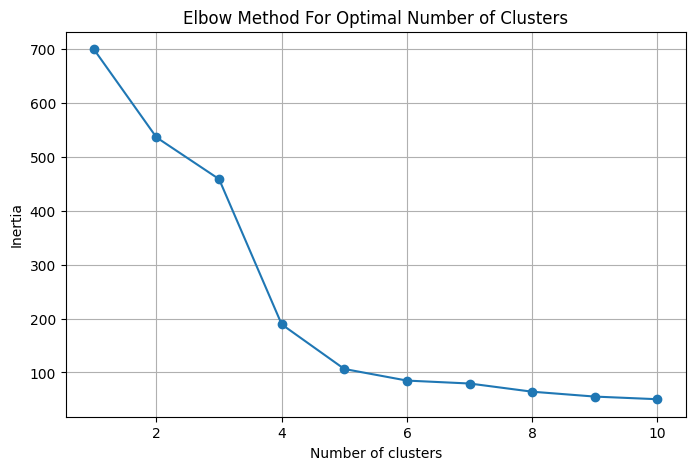

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method For Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [17]:
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)
sil_score = silhouette_score(scaled_features, cluster_labels)
print(f"Silhouette Score for {optimal_clusters} clusters: {sil_score:.4f}")

Silhouette Score for 4 clusters: 0.3355


In [18]:
df['cluster'] = cluster_labels
print("Cluster:")
print(df[['name', 'cluster']])

Cluster:
                         name  cluster
0     Cinthia Manullang, S.H.        2
1               Okto Prasasta        2
2          Jamalia Nurdiyanti        0
3           Belinda Sihombing        1
4    R. Oliva Oktaviani, S.T.        0
..                        ...      ...
95                Emas Irawan        0
96              Lalita Sirait        0
97  Mujur Mangunsong, S.I.Kom        2
98       Vanesa Irawan, S.Kom        2
99          Syahrini Palastri        2

[100 rows x 2 columns]


In [19]:
print("Cluster characteristics:")
cluster_summary = df.groupby('cluster')[features.columns].mean()
print(cluster_summary)


Cluster characteristics:
         total_achieved_task_count  avg_achievement_gap  \
cluster                                                   
0                              0.0             5.413043   
1                              1.0             0.000000   
2                              0.0             5.125000   
3                              0.0             9.000000   

         avg_performance_percentage  total_working_hours  total_working_day  \
cluster                                                                       
0                         93.910435             8.847826                1.0   
1                        100.000000             8.923077                1.0   
2                         94.356000             9.025000                1.0   
3                         89.410000             0.000000                0.0   

         total_permission_day  total_absent_day  months_of_service  
cluster                                                             
0      

In [21]:
cluster_names = {
    0: 'Cukup',
    1: 'Sangat Baik',
    2: 'Baik',
    3: 'Tidak Aktif'
}

df['cluster_label'] = df['cluster'].map(cluster_names)
df

,sk_employee,sk_time,name,month,year,total_achieved_task_count,avg_achievement_gap,avg_performance_percentage,total_working_hours,total_working_day,total_permission_day,total_absent_day,grade_code,months_of_service,is_overdue,next_grade_code,next_salary,next_promotion_duration,cluster,cluster_label
0,17,24,"Cinthia Manullang, S.H.",3,2025,0,5,94.68,8,1,0,0,GRD001,42,1,GRD002,5000000,24,2,Baik
1,58,69,Okto Prasasta,5,2025,0,3,96.88,8,1,0,0,GRD005,38,0,GRD005,15000000,60,2,Baik
2,33,42,Jamalia Nurdiyanti,4,2025,0,10,89.13,10,1,0,0,GRD001,99,1,GRD002,5000000,24,0,Cukup
3,68,80,Belinda Sihombing,5,2025,1,0,100.00,9,1,0,0,GRD003,82,1,GRD004,12000000,48,1,Sangat Baik
4,34,43,"R. Oliva Oktaviani, S.T.",4,2025,0,1,98.85,8,1,0,0,GRD003,90,1,GRD004,12000000,48,0,Cukup
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,80,94,Emas Irawan,6,2025,0,5,94.68,9,1,0,0,GRD001,92,1,GRD002,5000000,24,0,Cukup
96,73,87,Lalita Sirait,5,2025,0,5,94.44,8,1,0,0,GRD003,116,1,GRD004,12000000,48,0,Cukup
97,66,77,"Mujur Mangunsong, S.I.Kom",5,2025,0,4,95.35,9,1,0,0,GRD001,45,1,GRD002,5000000,24,2,Baik
98,27,36,"Vanesa Irawan, S.Kom",4,2025,0,6,93.26,9,1,0,0,GRD004,14,0,GRD004,12000000,48,2,Baik


In [22]:
df.to_csv('hasil_cluster.csv', index=False)